In [420]:
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance
from bertopic.vectorizers import  ClassTfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords

In [421]:
stoplist = list(set(stopwords.words('dutch'))) + list(set(stopwords.words('english'))) + list(set(stopwords.words('french')))
stoplist.extend(['pct', 'idem', 'wy', 'zyn' ,'zy','hy', 'pcts', 'dito', 'zoo', 'alhier', 'den', 'eene', 'ten', 'ter', 'zeer', 'eenen'])

In [422]:
import plotly.io as pio
pio.renderers.default = "colab"

In [423]:
texts = pd.read_csv("frame_df.csv")

In [424]:
sents = texts["sentence"]
condition = ["augmented" if "rag" in x else "baseline"for x in texts["condition"]]
languages = texts["language"]

In [425]:
sents

0        Ja, de impact van Napoleon Bonaparte op Engela...
1        Op Engeland: Napoleon had een directe en voora...
2        Dit leidde tot een ernstige economische crisis...
3        Engeland reageerde met een intensieve handelsa...
4        Bovendien werd de Britse Oorlogsschipvaart nav...
                               ...                        
10042    Historical accounts, such as those in the prov...
10043    Napoleon Bonaparte was a French military leade...
10044    Born in 1769 in Corsica, he became Emperor of ...
10045    He is renowned for his military genius, legal ...
10046    After being defeated at the Battle of Waterloo...
Name: sentence, Length: 10047, dtype: object

In [426]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("sentence-transformers/distiluse-base-multilingual-cased-v1", model_kwargs={"torch_dtype": "float16"})
embeddings = embedding_model.encode(sents, show_progress_bar=True)

Batches:   0%|          | 0/314 [00:00<?, ?it/s]

In [427]:
params = {  
            # TFIDF
            "reduce_frequent_words": True, "bm25_weighting": True,   
            "seed_words": [],
            "seed_multiplier": 4,
            # UMAP
            "n_neighbors": 10, "n_components": 5, "min_dist": 0.0, "metric_umap": "cosine", "random_state": 42,
            # HDBSCAN (change min_cluster_size for more/less topics?, default is 10, recommended to only increase above 10)
            "min_cluster_size": 45, "metric_hbd": "euclidean", "cluster_selection_method": "eom", "prediction_data": True,
            # Vectorizer model
            "stop_words": stoplist, "min_df": 2, "ngram_range": (1,2),
            # Representation models
            "diversity": 0.2
         }

In [428]:
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=params["reduce_frequent_words"], bm25_weighting=params["bm25_weighting"], 
                                     seed_words=params['seed_words'], seed_multiplier=params["seed_multiplier"])

In [429]:
umap_model = UMAP(n_neighbors=params["n_neighbors"], 
                  n_components=params["n_components"], 
                  min_dist=params["min_dist"], 
                  metric=params["metric_umap"], 
                  random_state=params["random_state"])

In [430]:
hdbscan_model = HDBSCAN(min_cluster_size=params["min_cluster_size"],
                        metric=params["metric_hbd"], 
                        cluster_selection_method=params["cluster_selection_method"], 
                        prediction_data=params["prediction_data"])

In [431]:
vectorizer_model = CountVectorizer(stop_words=stoplist, 
                                   min_df=params["min_df"], 
                                   ngram_range=params["ngram_range"])

In [432]:
representation_models = [KeyBERTInspired(), MaximalMarginalRelevance(diversity=params["diversity"])]

In [433]:
topic_model = BERTopic(

    # Pipeline models
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_models,
    top_n_words=3,
    verbose=True,
    ctfidf_model=ctfidf_model,
    # nr_topics="auto",
    calculate_probabilities=True,
)

# Train model
topics, probs = topic_model.fit_transform(sents, embeddings)

2025-10-20 11:17:18,444 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-20 11:17:22,057 - BERTopic - Dimensionality - Completed ✓
2025-10-20 11:17:22,057 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-20 11:17:22,881 - BERTopic - Cluster - Completed ✓
2025-10-20 11:17:22,890 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-20 11:17:24,483 - BERTopic - Representation - Completed ✓


In [434]:
new_topics = topic_model.reduce_outliers(sents, topics, strategy="embeddings")

In [435]:
topic_model.update_topics(sents, topics=new_topics)

2025-10-20 11:17:25,778 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [436]:
topic_model.save("topic_model/full_model_14_answers", serialization="safetensors", save_ctfidf=True, save_embedding_model="sentence-transformers/distiluse-base-multilingual-cased-v1")

In [437]:
topic_model.topic_labels_.values()

dict_values(['0_code_civil_legal_reforms', '1_him_un_is_as', '2_en_austria_zoals_autriche', '3_1804_keizer_frankrijk_in', '4_engeland_britse_de_leidde', '5_des_authoritarian_of_millions', '6_his_europe_claim_formal', '7_dutch_heavy_conscription_this', '8_document_his_and_him', '9_europe_across_of_he', '10_on_england_the_netherlands', '11_paix_document_la_que', '12_wordt_dat_document_oostenrijk', '13_angleterre_napoléon_la_pays', '14_notre_dame_1804_paris', '15_bonaparte_méchant_napoléon_un', '16_te_engeland_het_stelsel', '17_question_contenu_dépasse_disponibles', '18_consul_coup_1799_brumaire', '19_sur_les_pays_bas', '20_engeland_had_nederland_op', '21_1815_waterloo_1814_1812', '22_trafalgar_1805_nelson_naval', '23_1815_chute_bas_royaume', '24_netherlands_the_and_napoleon', '25_helena_saint_1821_waterloo', '26_bonaparte_popular_success_maneuvering', '27_treatment_document_concerns_about', '28_was_napoleon_bonaparte_een', '29_1810_annexed_into_het', '30_wordt_tijger_document_een', '31_i

In [438]:
topic_model.get_topic_freq(-1)/len(sents)

0.0

In [439]:
topic_model.visualize_heatmap()

In [495]:
all_ = pd.DataFrame({"topic":['_'.join(topic_model.get_topic_info(x)["Representation"][0]) for x in new_topics], "condition":condition, "language":languages})

In [496]:
all_ = all_.groupby(by=["topic", "condition", "language"]).value_counts().reset_index(name="count")

In [497]:
rag = all_[all_["condition"]=="augmented"].sort_values(by=["topic"], ascending=False).set_index("topic").drop("condition", axis=1)
baseline = all_[all_["condition"]=="baseline"].sort_values(by=["topic"], ascending=False).set_index('topic').drop("condition", axis=1)

Text(203.34722222222223, 0.5, 'delta counts')

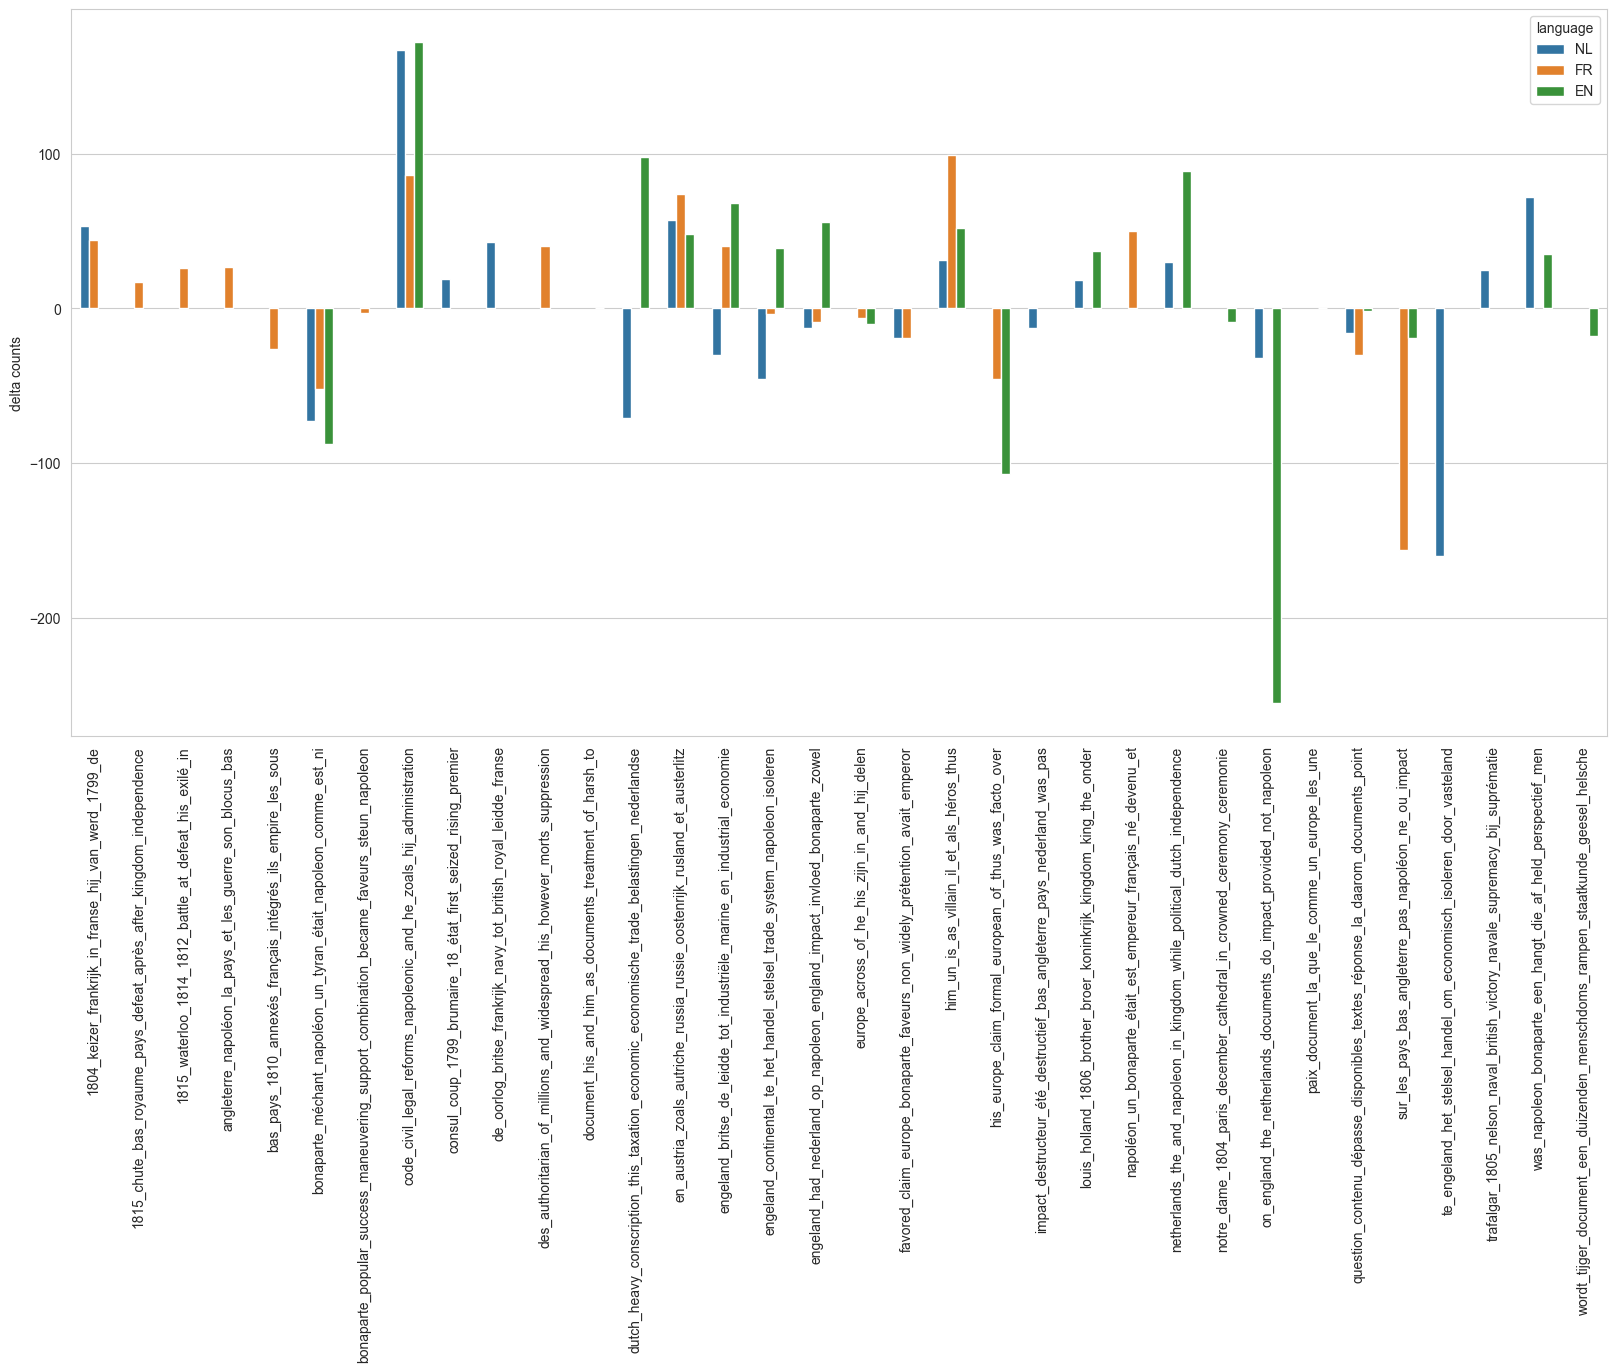

In [498]:
all_lang_chosen = pd.DataFrame()
for i, language in enumerate(["EN", "FR", "NL"]):
    sub_baseline = baseline[baseline["language"]==language].drop("language", axis=1)
    sub_rag = rag[rag["language"]==language].drop("language", axis=1)
    diff = sub_baseline-sub_rag
    chosen1 = diff.fillna(0).sort_values(by="count", ascending=False)[:10]
    chosen2 = diff.fillna(0).sort_values(by="count", ascending=True)[:10]
    all_chosen = pd.concat([chosen1, chosen2.sort_values(by="count", ascending=False)]).reset_index()
    all_chosen["language"] = language
    all_lang_chosen = pd.concat([all_lang_chosen, all_chosen])
    
all_lang_chosen = all_lang_chosen.reset_index(drop=True).sort_values(by="topic")
plt.figure(figsize=(20,8))
g = sns.barplot(
    data=all_lang_chosen,
    x="topic", y="count", hue="language", orient="v", width=0.6,
    # color=cmap[i]
)
plt.tight_layout()
plt.grid(True, axis='y') 
plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("delta counts")
# plt.savefig("figs/frame_counts_v.svg")

In [499]:
all_lang_chosen["count"] = [int(x) for x in all_lang_chosen['count']]

In [500]:
test = all_lang_chosen.groupby(["language", "topic"]).agg('sum').reset_index()

In [501]:
test

,language,topic,count
0,EN,bonaparte_méchant_napoléon_un_tyran_était_napo...,-88
1,EN,code_civil_legal_reforms_napoleonic_and_he_zoa...,172
2,EN,document_his_and_him_as_documents_treatment_of...,0
3,EN,dutch_heavy_conscription_this_taxation_economi...,98
4,EN,en_austria_zoals_autriche_russia_russie_oosten...,48
5,EN,engeland_britse_de_leidde_tot_industriële_mari...,68
6,EN,engeland_continental_te_het_handel_stelsel_tra...,39
7,EN,engeland_had_nederland_op_napoleon_england_imp...,56
8,EN,europe_across_of_he_his_zijn_in_and_hij_delen,-10
9,EN,him_un_is_as_villain_il_et_als_héros_thus,52


In [502]:
test = test.pivot(index="topic", columns=["language"], values="count").sort_index(axis=1, level=[0, 1]).fillna('0')

In [503]:
test.sort_values(by=["EN", "NL", "FR"])

language,EN,FR,NL
topic,,,
on_england_the_netherlands_documents_do_impact_provided_not_napoleon,-255.0,0,-32.0
his_europe_claim_formal_european_of_thus_was_facto_over,-107.0,-46.0,0
bonaparte_méchant_napoléon_un_tyran_était_napoleon_comme_est_ni,-88.0,-52.0,-73.0
sur_les_pays_bas_angleterre_pas_napoléon_ne_ou_impact,-19.0,-156.0,0
wordt_tijger_document_een_duizenden_menschdoms_rampen_staatkunde_geesel_helsche,-18.0,0,0
europe_across_of_he_his_zijn_in_and_hij_delen,-10.0,-6.0,0
notre_dame_1804_paris_december_cathedral_in_crowned_ceremony_ceremonie,-9.0,0,0
question_contenu_dépasse_disponibles_textes_réponse_la_daarom_documents_point,-2.0,-30.0,-16.0
document_his_and_him_as_documents_treatment_of_harsh_to,0.0,0,0


In [539]:
subset = texts[(texts["model"]=="Qwen3-235B-A22B-Instruct-2507") & (texts["language"]=="NL")] 
for idx, row in subset[subset["question"].str.contains('10')].drop(["Unnamed: 0", "model", "sentence"], axis=1).reset_index(drop=True).iterrows():
    print(row["translation"])
    print(row["language"])
    print(row["condition"])
    print('*'*60)

Napoleon Bonaparte's impact on England was primarily economic but ultimately counterproductive.
NL
rag_1_0
************************************************************
By introducing the continental system, a boycott of British goods, he wanted to isolate England economically and force it to capitulate.
NL
rag_1_1
************************************************************
However, this measure proved more damaging to European economies, including those of France and occupied territories, while England was relatively able to continue trading via other routes.
NL
rag_1_2
************************************************************
Napoleon's policy was therefore destructive for Europe, but less effective against England itself.
NL
rag_1_3
************************************************************
The impact on the Netherlands was indeed destructive.
NL
rag_1_4
************************************************************
After the incorporation of the Kingdom of Holland into the Frenc